# Inverse kinematics fit from the fly hackathon

In [1]:
from os import path as op
import sys
# sys.path.insert(0, op.abspath('/Users/eabe/Research/MyRepos/BiomechControl/models/fruitfly_v2/'))
sys.path.insert(0, op.abspath('/Users/eabe/Research/Github/flybody'))

from pathlib import Path
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import PIL.ImageDraw
from tqdm import tqdm

from dm_control import mujoco
from dm_control import mjcf
from dm_control.mujoco.wrapper.mjbindings import enums
from dm_control.mujoco.wrapper import mjbindings

import sys
sys.path.append('..')
# from dm_control.utils.inverse_kinematics import qpos_from_site_pose
from flybody.inverse_kinematics import qpos_from_site_xpos
from flybody.utils import display_video
from flybody.tasks.task_utils import retract_wings

In [2]:
def transform_frame(frame):
    """Transform a single frame from data to model reference frame."""
    # Rotate around z-axis.
    frame = frame[:, [1, 0, 2]]
    frame[:, 1] *= -1
    # Change units mm to cm.
    frame *= 0.1
    return frame
base_path = Path('/Users/eabe/Research/MyRepos/mujoco_mpc/Archive/fruitfly')
task_path = Path('/Users/eabe/Research/MyRepos/mujoco_mpc/mjpc/tasks/fruitfly/flyqpos2')
# task_path = Path('/Users/eabe/Research/MyRepos/mujoco_mpc/mjpc/tasks/fruitfly/flytrackingqpos')


# Load a single walking sequence

In [3]:

data_path = base_path / 'combined_wt_berlin_walking_v3.pq'
full_df = pd.read_parquet(data_path, engine='pyarrow')
bout_stats = full_df.groupby(['walking_bout_number','fullfile','Sex'])[['fictrac_delta_rot_lab_y_mms', 'fictrac_delta_rot_lab_z_deg/s']].agg(['mean','min','max','std','count'])
fast = (bout_stats[('fictrac_delta_rot_lab_y_mms','mean')] >= 12) & (bout_stats[('fictrac_delta_rot_lab_y_mms','min')] >= 10)
straight = (bout_stats[('fictrac_delta_rot_lab_z_deg/s','mean')].abs() <= 45) &\
           (bout_stats[('fictrac_delta_rot_lab_z_deg/s','min')] >= -60) &\
           (bout_stats[('fictrac_delta_rot_lab_z_deg/s','max')] <= 60)

#minlen =  bout_stats[('fictrac_delta_rot_lab_z_deg/s','count')] >= 300
# bout_stats[fast & straight].sort_values(('fictrac_delta_rot_lab_y_mms','min')).loc['walking_bout_number']

In [4]:
legs = ['T1_left', 'T1_right', 'T2_left', 'T2_right', 'T3_left', 'T3_right']
joints = ['coxa', 'femur', 'tibia', 'tarsus']
xpos_geoms = ['coxa', 'femur', 'tibia', 'tarsus', 'claw']
joint_names = [f'{joint}_{leg}' for leg in legs for joint in joints]
xpos_names = [f'{joint}_{leg}' for leg in legs for joint in xpos_geoms]
# physics.named.data.framepos[pos_names]
site_names = [f'tracking[{joint_name}]' for joint_name in xpos_names]

legs_data = ['L1', 'R1', 'L2','R2', 'L3','R3']
joints_data = ['A','B','C','D','E']
coords_data = ['_x','_y','_z']
joint_pos_columns = [leg + joint + coord 
                     for leg in legs_data
                     for joint in joints_data 
                     for coord in coords_data]

straight_bouts = bout_stats[fast & straight].index
straight_bout_num = np.array([i[0] for i in straight_bouts],dtype=int)
mean_straight_bout = (full_df[full_df['walking_bout_number'] == 14574][joint_pos_columns].values.reshape(-1,30, 3)).mean(axis=0)
ref_bout = (full_df[full_df['walking_bout_number'] == 14574][joint_pos_columns].values.reshape(-1,30, 3))
bout_dict = {'walking_bout{:02}'.format(n):{} for n in range(len(straight_bout_num))}

for n, bout_num in enumerate(straight_bout_num):
    bout = full_df[full_df['walking_bout_number'] == bout_num]
    bout_dict['walking_bout{:02}'.format(n)]['orig_xpos'] = bout[joint_pos_columns].values.reshape(-1,30, 3)
    bout_dict['walking_bout{:02}'.format(n)]['orig_xpos'] = bout_dict['walking_bout{:02}'.format(n)]['orig_xpos'] + (mean_straight_bout-np.mean(bout_dict['walking_bout{:02}'.format(n)]['orig_xpos'],axis=0))

In [5]:
full_df.shape

(575702, 452)

# Load the fly model

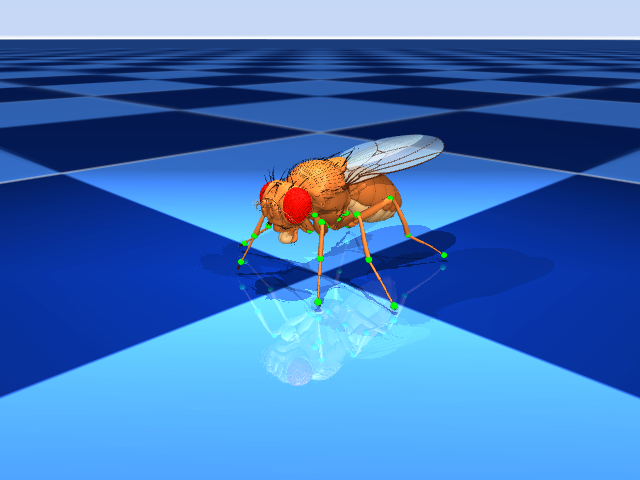

In [3]:
xml_path = task_path / 'task.xml'
# xml_path = task_path.parent / 'fruitfly_force.xml'
# xml_path = '/Users/eabe/Research/MyRepos/mujoco_mpc/mjpc/tasks/fruitfly/flytrackingqpos/task.xml'
# xml_path = '/Users/eabe/Research/MyRepos/mujoco_mpc/mjpc/tasks/fruitfly/fruitfly_force_ball.xml'

mjcf_model = mjcf.from_path(xml_path)

# Visualize fly as loaded.
physics = mjcf.Physics.from_mjcf_model(mjcf_model)
_ = physics.reset()
pixels = physics.render(camera_id=1, width=640, height=480)
PIL.Image.fromarray(pixels)

In [7]:
joint_names = [physics.model.joint(i).name for i in range(physics.model.njnt)]

((30,), 30, 30, 98)

In [77]:
legs = ['T1_left', 'T1_right', 'T2_left', 'T2_right', 'T3_left', 'T3_right']
joints = ['coxa', 'femur', 'tibia', 'tarsus']
xpos_geoms = ['coxa', 'femur', 'tibia', 'tarsus', 'claw']
joint_names = [f'{joint}_{leg}' for leg in legs for joint in joints]
xpos_names = [f'{joint}_{leg}' for leg in legs for joint in xpos_geoms]
site_names = [f'tracking[{joint_name}]' for joint_name in xpos_names]

legs_data = ['L1', 'R1', 'L2','R2', 'L3','R3']
joints_data = ['A','B','C','D','E']
coords_data = ['_x','_y','_z']
joint_pos_columns = [leg + joint + coord 
                     for leg in legs_data
                     for joint in joints_data 
                     for coord in coords_data]

joints_to_manipulate = ['coxa_abduct_T1_left',  'coxa_twist_T1_left',   'coxa_T1_left',   'femur_T1_left',  'femur_twist_T1_left',  'tibia_T1_left',    'tarsus_T1_left',
                        'coxa_abduct_T1_right', 'coxa_twist_T1_right',  'coxa_T1_right',  'femur_T1_right', 'femur_twist_T1_right', 'tibia_T1_right',   'tarsus_T1_right',
                        'coxa_abduct_T2_left',  'coxa_twist_T2_left',   'coxa_T2_left',   'femur_T2_left',  'femur_twist_T2_left',  'tibia_T2_left',    'tarsus_T2_left',
                        'coxa_abduct_T2_right', 'coxa_twist_T2_right',  'coxa_T2_right',  'femur_T2_right', 'femur_twist_T2_right', 'tibia_T2_right',   'tarsus_T2_right',
                        'coxa_abduct_T3_left',  'coxa_twist_T3_left',   'coxa_T3_left',   'femur_T3_left',  'femur_twist_T3_left',  'tibia_T3_left',    'tarsus_T3_left',
                        'coxa_abduct_T3_right', 'coxa_twist_T3_right',  'coxa_T3_right',  'femur_T3_right', 'femur_twist_T3_right', 'tibia_T3_right',   'tarsus_T3_right',]


In [7]:
joints_to_manipulate = [j.name for j in mjcf_model.find_all('joint')]

## Run IK from DM_Control

In [ ]:
for nbout,bout in enumerate(bout_dict.keys()):
    _ = physics.reset()
    # retract_wings(physics, prefix='')
    site_pos = physics.named.data.site_xpos[site_names]
    qpos = []
    all_frames = []
    for i in tqdm(range(bout_dict[bout]['orig_xpos'].shape[0])):
        # Prepare frame for fitting.
        frame = bout_dict[bout]['orig_xpos'][i] #(keypoint, xyz)
        frame = transform_frame(frame)
        frame += site_pos[0, :]  # Shift to body-coxa T1 left joint.
        all_frames.append(frame)
        # Run IK fit on current frame.
        res = qpos_from_site_xpos(physics, site_names, frame, joints_to_manipulate, reg_strength=.0001, inplace=True)
        # Store qpos results.
        qpos.append(res.qpos.copy())
    all_frames = np.stack(all_frames)
    qpos = np.stack(qpos)
    bout_dict[bout]['inv_xpos'] = all_frames
    bout_dict[bout]['inv_qpos'] = qpos  

In [34]:
import io_dict_to_hdf5 as ioh5
ioh5.save('./bout_dict_free_DM_reg.h5',bout_dict,)

### Save xml key frames

In [129]:
qpos_all = np.concatenate([bout_dict['walking_bout{:02}'.format(n)]['inv_qpos'] for n in range(len(bout_dict.keys()))])
qvel_all = np.concatenate([np.diff(bout_dict['walking_bout{:02}'.format(n)]['inv_qpos'], axis=0, prepend=bout_dict['walking_bout{:02}'.format(n)]['inv_qpos'][0:1,:]) for n in range(len(bout_dict.keys()))])
kp_all = np.concatenate([bout_dict['walking_bout{:02}'.format(n)]['inv_xpos'] for n in range(len(bout_dict.keys()))])


In [ ]:
walking_bout_n = 1
root = mjcf.RootElement()
root.keyframe.add('key', name=f'walk{walking_bout_n}_1', mpos=kp_all[0].flatten(),qpos=qpos_all[0].flatten(),qvel=qvel_all[0].flatten())
for n in tqdm(range(2,kp_all.shape[0])):
    root.keyframe.add('key', name=f'walk{walking_bout_n}_{n}', mpos=kp_all[n].flatten(),qpos=qpos_all[n].flatten())
    
# save xml file
keyframe_path = task_path / 'keyframes/'
mjcf.export_with_assets(root, keyframe_path, f'Fly_walk_qpos2{walking_bout_n}.xml')


In [ ]:
plt.plot(bout_dict['walking_bout{:02}'.format(2)]['inv_qpos'])
plt.show()

In [ ]:
# Generate video of fitted poses.

camera_id = 1 # Side view.

# Hide all sites.
scene_option = mujoco.wrapper.core.MjvOption()
scene_option.sitegroup[:] = [1, 1, 1, 1, 1, 1]
scene_option.flags[enums.mjtVisFlag.mjVIS_CONTACTPOINT] = True
# scene_option.flags[mujoco.mjtVisFlag.mjVIS_CONTACTFORCE] = True

qpos = bout_dict['walking_bout{:02}'.format(n)]['inv_qpos']
mocap = bout_dict['walking_bout{:02}'.format(n)]['inv_xpos']
#retract_wings(physics)
n=0
video_frames = []
for q,kp in tqdm(zip(qpos, mocap)):
    with physics.reset_context():
        physics.data.qpos = q.copy()
        physics.data.mocap_pos = kp.copy()
    pixels = physics.render(camera_id=camera_id, width=640, height=480, scene_option=scene_option)
    video_frames.append(pixels)
    

In [ ]:
display_video(video_frames, framerate=30)

In [10]:
# import io_dict_to_hdf5 as ioh5
# ioh5.save('./bout_dict_free.h5',bout_dict,)

# Visualize a single frame

In [25]:
import matplotlib as mpl
def map_discrete_cbar(cmap,N):
    cmap = plt.get_cmap(cmap,N+1)
    bounds = np.arange(-.5,N+1)
    norm = mpl.colors.BoundaryNorm(bounds, cmap.N)
    return cmap, norm

In [ ]:
frame_idx = 0
frame0 = bout_dict['walking_bout{:02}'.format(n)]['orig_xpos'][frame_idx, :].reshape(30, 3) # (keypoint, xyz)
fly_skel = np.array([(n,n+1) for n in range(29)])
fly_skel = np.stack((fly_skel[:4],fly_skel[5:9],fly_skel[10:14],fly_skel[15:19],fly_skel[20:24],fly_skel[25:30],))

cmap,norm = map_discrete_cbar('turbo',6)
fig, axs = plt.subplots(1,2,figsize=(12, 4))

ax=axs[0]
ax.scatter(frame0[:, 0], frame0[:, 1], c=np.arange(frame0.shape[0]),cmap=cmap)
for n in range(fly_skel.shape[0]):
    ax.plot(frame0[fly_skel[n], 0], frame0[fly_skel[n], 1],c=cmap(n))
ax.axis('equal')
ax.set_xlabel('x (mm)')
ax.set_ylabel('y (mm)')
ax.set_title('top-down view')

ax = axs[1]
ax.scatter(frame0[:, 0], frame0[:, 2], c=np.arange(frame0.shape[0]),cmap=cmap)
for n in range(fly_skel.shape[0]):
    ax.plot(frame0[fly_skel[n], 0], frame0[fly_skel[n], 2],c=cmap(n))
ax.axis('equal')
ax.set_xlabel('x (mm)')
ax.set_ylabel('z (mm)')
ax.set_title('side view')
plt.show()

## Compare model's initial position with first data frame

In [18]:
# Transform frame.
frame0 = transform_frame(frame0)
site_pos = physics.named.data.site_xpos[site_names]
# Shift to match origin of data and model.
frame0 += site_pos[0, :]  # Body-coxa T1 left joint is the data origin.

In [ ]:
# Compare site positions after fitting.
site_pos = physics.named.data.site_xpos[site_names]

fig, axs = plt.subplots(1,1)
ax = axs
ax.scatter(frame0[:, 0], frame0[:, 1], c=np.arange(frame0.shape[0]), label='data', cmap=cmap)
ax.scatter(site_pos[:, 0], site_pos[:, 1], marker='x', s=100, c=np.arange(site_pos.shape[0]), label='fitted model', cmap=cmap)
for n in range(fly_skel.shape[0]):
    ax.plot(site_pos[fly_skel[n], 0], site_pos[fly_skel[n], 1], c=cmap(n))
    ax.plot(frame0[fly_skel[n], 0], frame0[fly_skel[n], 1], c=cmap(n))
ax.axis('equal')
ax.set_title('site positions after test-fitting one frame')
ax.set_xlabel('x (cm)')
ax.set_ylabel('y (cm)')
ax.legend()
ax.grid()

## Try fitting one frame

In [ ]:
_ = physics.reset()
# retract_wings(physics, prefix='')

# Run IK fit on one frame.
res = qpos_from_site_xpos(physics, site_names, frame0, joints_to_manipulate, inplace=True)

In [ ]:
# Compare site positions after fitting.
site_pos = physics.named.data.site_xpos[site_names]

fig, axs = plt.subplots(1,1)
ax = axs
ax.scatter(frame0[:, 0], frame0[:, 1], c=np.arange(frame0.shape[0]), label='data', cmap=cmap)
ax.scatter(site_pos[:, 0], site_pos[:, 1], marker='x', s=100, c=np.arange(site_pos.shape[0]), label='fitted model', cmap=cmap)
for n in range(fly_skel.shape[0]):
    ax.plot(site_pos[fly_skel[n], 0], site_pos[fly_skel[n], 1], c=cmap(n))
    ax.plot(frame0[fly_skel[n], 0], frame0[fly_skel[n], 1], c=cmap(n))
ax.axis('equal')
ax.set_title('site positions after test-fitting one frame')
ax.set_xlabel('x (cm)')
ax.set_ylabel('y (cm)')
ax.legend()
ax.grid()

In [ ]:
# Generate video of fitted poses.
qpos_frames = res.qpos.copy()
mode_frames = frame0.copy()
camera_id = 1 # Side view.

# Hide all sites.
scene_option = mujoco.wrapper.core.MjvOption()
scene_option.sitegroup[:] = [1, 1, 1, 1, 1, 0]
scene_option.flags[mujoco.mjtVisFlag.mjVIS_TRANSPARENT] = True
# scene_option.flags[enums.mjtVisFlag.mjVIS_CONTACTPOINT] = True
# scene_option.flags[mujoco.mjtVisFlag.mjVIS_CONTACTFORCE] = True


#retract_wings(physics)

video_frames = []
with physics.reset_context():
    physics.data.qpos = qpos_frames.copy()
    physics.data.mocap_pos = mode_frames.copy()
pixels = physics.render(camera_id=camera_id, width=640, height=480, scene_option=scene_option)
    
# Visualize fly as loaded.
PIL.Image.fromarray(pixels)

# Try fitting all frames all bouts

In [54]:
data_path = base_path / 'combined_wt_berlin_walking_v3.pq'
full_df = pd.read_parquet(data_path, engine='pyarrow')
bout_stats = full_df.groupby(['walking_bout_number','fullfile','Sex'])[['fictrac_delta_rot_lab_y_mms', 'fictrac_delta_rot_lab_z_deg/s']].agg(['mean','min','max','std','count'])
fast = (bout_stats[('fictrac_delta_rot_lab_y_mms','mean')] >= 12) & (bout_stats[('fictrac_delta_rot_lab_y_mms','min')] >= 10)
straight = (bout_stats[('fictrac_delta_rot_lab_z_deg/s','mean')].abs() <= 45) &\
           (bout_stats[('fictrac_delta_rot_lab_z_deg/s','min')] >= -60) &\
           (bout_stats[('fictrac_delta_rot_lab_z_deg/s','max')] <= 60)


In [ ]:

xml_path = task_path / 'task.xml'
# xml_path = task_path.parent / 'fruitfly_force.xml'
# xml_path = '/Users/eabe/Research/MyRepos/mujoco_mpc/mjpc/tasks/fruitfly/fruitfly_freeforce.xml'
mjcf_model = mjcf.from_path(xml_path)

# Visualize fly as loaded.
physics = mjcf.Physics.from_mjcf_model(mjcf_model)
# physics.model.geom('floor').pos = (0, 0, -.137)
_ = physics.reset()
# retract_wings(physics, prefix='')
# physics.step()
pixels = physics.render(camera_id=1, width=640, height=480)
PIL.Image.fromarray(pixels)

In [56]:
legs = ['T1_left', 'T1_right', 'T2_left', 'T2_right', 'T3_left', 'T3_right']
joints = ['coxa', 'femur', 'tibia', 'tarsus']
xpos_geoms = ['coxa', 'femur', 'tibia', 'tarsus', 'claw']
joint_names = [f'{joint}_{leg}' for leg in legs for joint in joints]
xpos_names = [f'{joint}_{leg}' for leg in legs for joint in xpos_geoms]
# physics.named.data.framepos[pos_names]
site_names = [f'tracking[{joint_name}]' for joint_name in xpos_names]

legs_data = ['L1', 'R1', 'L2','R2', 'L3','R3']
joints_data = ['A','B','C','D','E']
coords_data = ['_x','_y','_z']
joint_pos_columns = [leg + joint + coord 
                     for leg in legs_data
                     for joint in joints_data 
                     for coord in coords_data]

straight_bouts = bout_stats[fast & straight].index
straight_bout_num = np.array([i[0] for i in straight_bouts],dtype=int)
mean_straight_bout = (full_df[full_df['walking_bout_number'] == 14574][joint_pos_columns].values.reshape(-1,30, 3)).mean(axis=0)
ref_bout = (full_df[full_df['walking_bout_number'] == 14574][joint_pos_columns].values.reshape(-1,30, 3))
bout_dict = {'walking_bout{:02}'.format(n):{} for n in range(len(straight_bout_num))}

for n, bout_num in enumerate(straight_bout_num):
    bout = full_df[full_df['walking_bout_number'] == bout_num]
    bout_dict['walking_bout{:02}'.format(n)]['orig_xpos'] = bout[joint_pos_columns].values.reshape(-1,30, 3)
    bout_dict['walking_bout{:02}'.format(n)]['orig_xpos'] = bout_dict['walking_bout{:02}'.format(n)]['orig_xpos'] + (mean_straight_bout-np.mean(bout_dict['walking_bout{:02}'.format(n)]['orig_xpos'],axis=0))

In [ ]:

joints_to_manipulate = ['coxa_abduct_T1_left',  'coxa_twist_T1_left',   'coxa_T1_left',   'femur_T1_left',  'femur_twist_T1_left',  'tibia_T1_left',    'tarsus_T1_left',
                        'coxa_abduct_T1_right', 'coxa_twist_T1_right',  'coxa_T1_right',  'femur_T1_right', 'femur_twist_T1_right', 'tibia_T1_right',   'tarsus_T1_right',
                        'coxa_abduct_T2_left',  'coxa_twist_T2_left',   'coxa_T2_left',   'femur_T2_left',  'femur_twist_T2_left',  'tibia_T2_left',    'tarsus_T2_left',
                        'coxa_abduct_T2_right', 'coxa_twist_T2_right',  'coxa_T2_right',  'femur_T2_right', 'femur_twist_T2_right', 'tibia_T2_right',   'tarsus_T2_right',
                        'coxa_abduct_T3_left',  'coxa_twist_T3_left',   'coxa_T3_left',   'femur_T3_left',  'femur_twist_T3_left',  'tibia_T3_left',    'tarsus_T3_left',
                        'coxa_abduct_T3_right', 'coxa_twist_T3_right',  'coxa_T3_right',  'femur_T3_right', 'femur_twist_T3_right', 'tibia_T3_right',   'tarsus_T3_right',]


for nbout,bout in enumerate(list(bout_dict.keys())[:1]):
    _ = physics.reset()
    # retract_wings(physics, prefix='')
    site_pos = physics.named.data.site_xpos[site_names]
    qpos = []
    all_frames = []
    for i in tqdm(range(bout_dict[bout]['orig_xpos'].shape[0])):
        # Prepare frame for fitting.
        frame = bout_dict[bout]['orig_xpos'][i] #(keypoint, xyz)
        frame = transform_frame(frame)
        frame += site_pos[0, :]  # Shift to body-coxa T1 left joint.
        all_frames.append(frame)
        # _ = physics.reset()
        # Run IK fit on current frame.
        res = qpos_from_site_xpos(physics, site_names, frame, joints_to_manipulate, reg_strength=.0001 inplace=True)
        # Store qpos results.
        qpos.append(res.qpos.copy())
    all_frames = np.stack(all_frames)
    qpos = np.stack(qpos)
    bout_dict[bout]['inv_xpos'] = all_frames
    bout_dict[bout]['inv_qpos'] = qpos  

In [ ]:
# Generate video of fitted poses.
n=0
qpos_frames = bout_dict['walking_bout{:02}'.format(n)]['inv_qpos'].copy()
mpos_frames = bout_dict['walking_bout{:02}'.format(n)]['inv_xpos'].copy()
camera_id = 1 # Side view.

# Hide all sites.
scene_option = mujoco.wrapper.core.MjvOption()
scene_option.sitegroup[:] = [1, 1, 1, 1, 1, 0]
# scene_option.flags[enums.mjtVisFlag.mjVIS_CONTACTPOINT] = True
# scene_option.flags[mujoco.mjtVisFlag.mjVIS_CONTACTFORCE] = True


#retract_wings(physics)

video_frames_DM = []
for t,q in tqdm(enumerate(qpos_frames)):
    with physics.reset_context():
        physics.data.qpos = qpos_frames[t].copy()
        physics.data.mocap_pos = mpos_frames[t].copy()
    pixels = physics.render(camera_id=camera_id, width=640, height=480, scene_option=scene_option)
    video_frames_DM.append(pixels)

In [ ]:
display_video(video_frames_DM, framerate=50)

In [ ]:
qpos_frames = np.concatenate([bout_dict['walking_bout{:02}'.format(n)]['inv_qpos'] for n in range(len(bout_dict.keys()))])[:,7:]
mpos_frames = np.concatenate([bout_dict['walking_bout{:02}'.format(n)]['inv_xpos'] for n in range(len(bout_dict.keys()))])
qvel_frames = np.diff(qpos_frames, axis=0, prepend=qpos_frames[0:1,:])
qpos_frames.shape,mpos_frames.shape,qvel_frames.shape,

In [ ]:
t = 0
walking_bout_n = 1
root = mjcf.RootElement()
root.keyframe.add('key', name=f'DM_{walking_bout_n}_1', mpos=mpos_frames[0].flatten(),qpos=qpos_frames[0].flatten(),qvel=qvel_frames[0].flatten())
for n in range(2,qpos_frames.shape[0]):
    root.keyframe.add('key', name=f'DM_{walking_bout_n}_{n}', mpos=mpos_frames[n].flatten(),qpos=qpos_frames[n].flatten())
    
# save xml file
# root = root.default.remove()
keyframe_path = task_path / 'keyframes/'
filename = f'Fly_free_qpos{walking_bout_n}_DM.xml'
mjcf.export_with_assets(root, keyframe_path,filename)
keyframe_path/filename

In [ ]:
tredmill_df = pd.read_csv(base_path/'wt_berlin_linear_treadmill_dataset.csv')
kp_names = ['head', 'thorax', 'abdomen', 'r1', 'r2', 'r3', 'l1', 'l2', 'l3']
coords = ['_x', '_y', '_z']
df_names = [kp+coord for kp in kp_names for coord in coords]

# IK from Stac

In [4]:
import pickle
import numpy as np
from pathlib import Path
from typing import Union, Dict
import io_dict_to_hdf5 as ioh5
stac_data = Path('/Users/eabe/Research/MyRepos/mujoco_mpc/Archive/fruitfly/transform_tethered.p')
dm_ik_path = Path('/Users/eabe/Research/MyRepos/mujoco_mpc/bout_dict_free_DM_reg.h5')

In [7]:
# Load data
bout_dict = ioh5.load(dm_ik_path)

with open(stac_data, "rb") as file:
    d = pickle.load(file)
    qposes = np.array(d["qpos"])
    kp_data = np.array(d["kp_data"])
    kp_names = d["kp_names"]
    offsets = d["offsets"]

In [8]:
qposes.shape

(5700, 36)

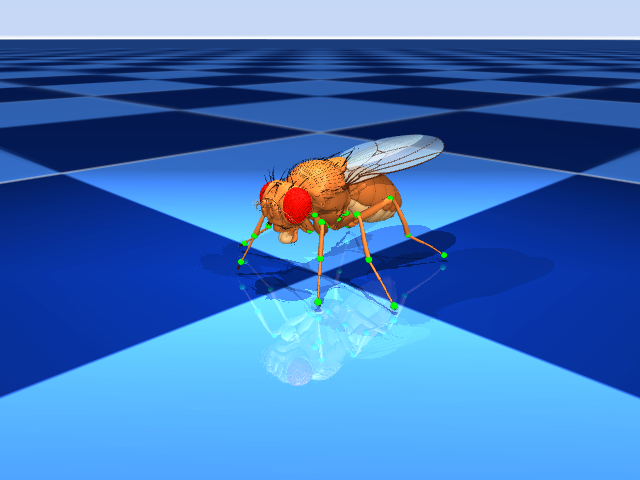

In [9]:
# xml_path = task_path / 'task.xml'
# xml_path = '/Users/eabe/Research/MyRepos/mujoco_mpc/mjpc/tasks/fruitfly/flytrackingqpos/task.xml'
mjcf_model = mjcf.from_path(xml_path)

# Visualize fly as loaded.
physics = mjcf.Physics.from_mjcf_model(mjcf_model)
_ = physics.reset()
pixels = physics.render(camera_id=1, width=640, height=480)
PIL.Image.fromarray(pixels)

array([[ 0.00569876,  0.00456966,  0.00260866, ...,  0.10277424,
        -0.07107203, -0.11082014],
       [ 0.00436019,  0.00394006,  0.00391392, ...,  0.14822291,
        -0.04318162, -0.0459994 ],
       [ 0.00342333,  0.00346561,  0.00412052, ...,  0.18754995,
        -0.03883128, -0.02424595],
       ...,
       [ 0.00309342,  0.00320041,  0.00515332, ...,  0.6063675 ,
         0.5243038 ,  0.5688621 ],
       [ 0.00337979,  0.0038812 ,  0.00528139, ...,  0.6305862 ,
         0.49981272,  0.5612661 ],
       [ 0.00352053,  0.00474877,  0.00547356, ...,  0.6481214 ,
         0.46201533,  0.52102077]], dtype=float32)

In [10]:
# Generate video of fitted poses.
qpos_frames = qposes[:601,:].copy()
mod_frames = kp_data.reshape(-1,30,3).copy() + offsets
camera_id = 1 # Side view.

# Show all sites.
scene_option = mujoco.wrapper.core.MjvOption()
scene_option.sitegroup[:] = [1, 1, 1, 1, 1, 0]
scene_option.flags[enums.mjtVisFlag.mjVIS_CONTACTPOINT] = True
scene_option.flags[mujoco.mjtVisFlag.mjVIS_CONTACTFORCE] = True


#retract_wings(physics)

video_frames_STAC = []
for t,q in tqdm(enumerate(qpos_frames)):
    with physics.reset_context():
        physics.data.qpos = qpos_frames[t].copy()
        physics.data.mocap_pos = mod_frames[t].copy()
        physics.step()
    pixels = physics.render(camera_id=camera_id, width=640, height=480, scene_option=scene_option)
    video_frames_STAC.append(pixels)

601it [00:12, 48.65it/s]


In [11]:
display_video(video_frames_STAC, framerate=50)

In [42]:
video_frames_all = []
for frame_stac,frame_dm in zip(video_frames_STAC,video_frames_DM):
    video_frames_all.append(np.concatenate([frame_dm,frame_stac],axis=1))

In [ ]:
display_video(video_frames_all, framerate=50)

In [13]:
stac_dict = {'qpos':np.array(qposes), 'kp_data':np.array(kp_data), 'offsets':np.array(offsets)}
ioh5.save(stac_data.parent/'stac_dict', stac_dict)

### Save xml key frames

In [12]:
qpos_frames = qposes.copy()
qvel_frames = np.diff(qpos_frames, axis=0, prepend=qpos_frames[0:1,:])
mod_frames = kp_data.reshape(-1,30,3).copy()# + offsets
# mod_frames = np.concatenate([bout_dict[key]['inv_xpos'] for key in bout_dict.keys()],axis=0)# + offsets


In [13]:
t = 0
walking_bout_n = 1
root = mjcf.RootElement()
root.keyframe.add('key', name=f'Stac_{walking_bout_n}_1', mpos=mod_frames[0].flatten(),qpos=qpos_frames[0].flatten())
for n in range(2,qpos_frames.shape[0]):
    root.keyframe.add('key', name=f'Stac_{walking_bout_n}_{n}', mpos=mod_frames[n].flatten(),qpos=qpos_frames[n].flatten())
    
# save xml file
# root = root.default.remove()
keyframe_path = task_path / 'keyframes/'
filename = f'Fly_qpos{walking_bout_n}_stac.xml'
mjcf.export_with_assets(root, keyframe_path,filename)
keyframe_path/filename

PosixPath('/Users/eabe/Research/MyRepos/mujoco_mpc/mjpc/tasks/fruitfly/flyqpos2/keyframes/Fly_qpos1_stac.xml')

In [ ]:
len(physics.named.model.actuator_actnum.axes.row.names)
# dir(physics.named.model)

In [20]:
import pickle
import numpy as np
from pathlib import Path
from dm_control import mjcf

stac_data = Path('/Users/eabe/Research/MyRepos/mujoco_mpc/Archive/fruitfly/transform.p')
# xml_path = Path('/Users/eabe/Research/MyRepos/mujoco_mpc/mjpc/tasks/fruitfly/flytrackingqpos/task.xml')
xml_path = Path('/Users/eabe/Research/MyRepos/mujoco_mpc/mjpc/tasks/fruitfly/fruitfly_force_ball.xml')

with open(stac_data, "rb") as file:
    d = pickle.load(file)
    qposes = np.array(d["qpos"])
    kp_data = np.array(d["kp_data"])
    kp_names = d["kp_names"]
    offsets = d["offsets"]
mjcf_model = mjcf.from_path(xml_path)
physics = mjcf.Physics.from_mjcf_model(mjcf_model)
joint_ranges = physics.named.model.jnt_range
joints_to_manipulate = [j.name for j in mjcf_model.find_all('joint')]

for n,(jointrange,minjnt,maxjnt) in enumerate(zip(joint_ranges, np.min(qposes[:,6:],axis=0),np.max(qposes[:,6:],axis=0))):
    print('{},{}, xml_range: {}, min:{:.04f}, max:{:.04f}, Valid: {}'.format(n,joints_to_manipulate[n],jointrange,minjnt,maxjnt, (minjnt>=jointrange[0])&(maxjnt<=jointrange[1])))

0,coxa_T1_left, xml_range: [0.  1.5], min:-0.0396, max:0.1042, Valid: False
1,femur_twist_T1_left, xml_range: [-1.  1.], min:-1.0000, max:-0.1671, Valid: True
2,femur_T1_left, xml_range: [-0.15  2.  ], min:-0.1240, max:0.8000, Valid: True
3,tibia_T1_left, xml_range: [-1.35  1.3 ], min:-0.2073, max:0.8803, Valid: True
4,coxa_T1_right, xml_range: [0.  1.5], min:-0.1500, max:1.1095, Valid: False
5,femur_twist_T1_right, xml_range: [-1.  1.], min:-0.0776, max:1.3000, Valid: False
6,femur_T1_right, xml_range: [-0.15  2.  ], min:-0.6024, max:0.2459, Valid: False
7,tibia_T1_right, xml_range: [-1.35  1.3 ], min:-0.5708, max:0.5073, Valid: True
8,coxa_T2_left, xml_range: [0.  1.5], min:-0.9464, max:-0.0533, Valid: False
9,femur_twist_T2_left, xml_range: [-1.  1.], min:-0.1500, max:0.8804, Valid: True
10,femur_T2_left, xml_range: [-0.15  2.  ], min:-0.3426, max:1.1576, Valid: False
11,tibia_T2_left, xml_range: [-1.35  1.3 ], min:-0.2633, max:-0.0055, Valid: True
12,coxa_T2_right, xml_range: [0.  

In [23]:
np.zeros_like(qposes[0,:-1])

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0.], dtype=float32)

In [ ]:
physics.named.model.body_ipos

In [ ]:
physics.named.model.body_iquat
# dir(physics.named.model)

In [ ]:
mj_model.body_quat[0]


In [ ]:
# physics.named.model.body_pos['thorax']


In [ ]:
joint_names = [physics.model.joint(i).name for i in range(physics.model.njnt)]
joint_names

In [6]:
qpos_dm = bout_dict['walking_bout00']['inv_qpos'][:,7:]
qpos_stac = qposes[:601,7:]

In [ ]:
fig, axs = plt.subplots(1,2,figsize=(12, 4), sharey=True)
ax = axs[0]
ax.plot(qpos_dm)
ax.set_title('DM IK')
ax.set_xlabel('timesteps')
ax.set_ylabel('qpos (rad)')

ax = axs[1]
ax.plot(qpos_stac)
ax.set_title('STAC IK')
ax.set_xlabel('timesteps')
ax.set_ylabel('qpos (rad)')
plt.savefig('qpos_comparison.png')

In [ ]:

for n,(jointrange,minjnt,maxjnt) in enumerate(zip(joint_ranges, np.min(qpos_dm,axis=0),np.max(qpos_dm,axis=0))):
    print('{},{}, xml_range: {}, min:{}, max:{}, Valid: {}'.format(n,joints_to_manipulate[n],jointrange,minjnt,maxjnt, (minjnt>jointrange[0])&(maxjnt<jointrange[1])))


In [ ]:
joints_to_manipulate = [j.name for j in mjcf_model.find_all('joint')]
fig, axs = plt.subplots(7,6,figsize=(30, 30))
for n,ax in enumerate(axs.flatten()):
    ax.plot(qposes[:,n])
    ax.hlines(joint_ranges[n][0],0,qposes.shape[0],'b',linestyles='dashed')
    ax.hlines(joint_ranges[n][1],0,qposes.shape[0],'r',linestyles='dashed')
    ax.set_title(joints_to_manipulate[n])

In [42]:

# For testing whether a number is close to zero
_FLOAT_EPS = np.finfo(np.float64).eps
_EPS4 = _FLOAT_EPS * 4.0

def euler2mat(euler):
    """ Convert Euler Angles to Rotation Matrix.  See rotation.py for notes """
    euler = np.asarray(euler, dtype=np.float64)
    assert euler.shape[-1] == 3, "Invalid shaped euler {}".format(euler)

    ai, aj, ak = -euler[..., 2], -euler[..., 1], -euler[..., 0]
    si, sj, sk = np.sin(ai), np.sin(aj), np.sin(ak)
    ci, cj, ck = np.cos(ai), np.cos(aj), np.cos(ak)
    cc, cs = ci * ck, ci * sk
    sc, ss = si * ck, si * sk

    mat = np.empty(euler.shape[:-1] + (3, 3), dtype=np.float64)
    mat[..., 2, 2] = cj * ck
    mat[..., 2, 1] = sj * sc - cs
    mat[..., 2, 0] = sj * cc + ss
    mat[..., 1, 2] = cj * sk
    mat[..., 1, 1] = sj * ss + cc
    mat[..., 1, 0] = sj * cs - sc
    mat[..., 0, 2] = -sj
    mat[..., 0, 1] = cj * si
    mat[..., 0, 0] = cj * ci
    return mat


def euler2quat(euler):
    """ Convert Euler Angles to Quaternions.  See rotation.py for notes """
    euler = np.asarray(euler, dtype=np.float64)
    assert euler.shape[-1] == 3, "Invalid shape euler {}".format(euler)

    ai, aj, ak = euler[..., 2] / 2, -euler[..., 1] / 2, euler[..., 0] / 2
    si, sj, sk = np.sin(ai), np.sin(aj), np.sin(ak)
    ci, cj, ck = np.cos(ai), np.cos(aj), np.cos(ak)
    cc, cs = ci * ck, ci * sk
    sc, ss = si * ck, si * sk

    quat = np.empty(euler.shape[:-1] + (4,), dtype=np.float64)
    quat[..., 0] = cj * cc + sj * ss
    quat[..., 3] = cj * sc - sj * cs
    quat[..., 2] = -(cj * ss + sj * cc)
    quat[..., 1] = cj * cs - sj * sc
    return quat


def mat2euler(mat):
    """ Convert Rotation Matrix to Euler Angles.  See rotation.py for notes """
    mat = np.asarray(mat, dtype=np.float64)
    assert mat.shape[-2:] == (3, 3), "Invalid shape matrix {}".format(mat)

    cy = np.sqrt(mat[..., 2, 2] * mat[..., 2, 2] + mat[..., 1, 2] * mat[..., 1, 2])
    condition = cy > _EPS4
    euler = np.empty(mat.shape[:-1], dtype=np.float64)
    euler[..., 2] = np.where(condition,
                             -np.arctan2(mat[..., 0, 1], mat[..., 0, 0]),
                             -np.arctan2(-mat[..., 1, 0], mat[..., 1, 1]))
    euler[..., 1] = np.where(condition,
                             -np.arctan2(-mat[..., 0, 2], cy),
                             -np.arctan2(-mat[..., 0, 2], cy))
    euler[..., 0] = np.where(condition,
                             -np.arctan2(mat[..., 1, 2], mat[..., 2, 2]),
                             0.0)
    return euler


def mat2quat(mat):
    """ Convert Rotation Matrix to Quaternion.  See rotation.py for notes """
    mat = np.asarray(mat, dtype=np.float64)
    assert mat.shape[-2:] == (3, 3), "Invalid shape matrix {}".format(mat)

    Qxx, Qyx, Qzx = mat[..., 0, 0], mat[..., 0, 1], mat[..., 0, 2]
    Qxy, Qyy, Qzy = mat[..., 1, 0], mat[..., 1, 1], mat[..., 1, 2]
    Qxz, Qyz, Qzz = mat[..., 2, 0], mat[..., 2, 1], mat[..., 2, 2]
    # Fill only lower half of symmetric matrix
    K = np.zeros(mat.shape[:-2] + (4, 4), dtype=np.float64)
    K[..., 0, 0] = Qxx - Qyy - Qzz
    K[..., 1, 0] = Qyx + Qxy
    K[..., 1, 1] = Qyy - Qxx - Qzz
    K[..., 2, 0] = Qzx + Qxz
    K[..., 2, 1] = Qzy + Qyz
    K[..., 2, 2] = Qzz - Qxx - Qyy
    K[..., 3, 0] = Qyz - Qzy
    K[..., 3, 1] = Qzx - Qxz
    K[..., 3, 2] = Qxy - Qyx
    K[..., 3, 3] = Qxx + Qyy + Qzz
    K /= 3.0
    # TODO: vectorize this -- probably could be made faster
    q = np.empty(K.shape[:-2] + (4,))
    it = np.nditer(q[..., 0], flags=['multi_index'])
    while not it.finished:
        # Use Hermitian eigenvectors, values for speed
        vals, vecs = np.linalg.eigh(K[it.multi_index])
        # Select largest eigenvector, reorder to w,x,y,z quaternion
        q[it.multi_index] = vecs[[3, 0, 1, 2], np.argmax(vals)]
        # Prefer quaternion with positive w
        # (q * -1 corresponds to same rotation as q)
        if q[it.multi_index][0] < 0:
            q[it.multi_index] *= -1
        it.iternext()
    return q


def quat2euler(quat):
    """ Convert Quaternion to Euler Angles.  See rotation.py for notes """
    return mat2euler(quat2mat(quat))


def subtract_euler(e1, e2):
    assert e1.shape == e2.shape
    assert e1.shape[-1] == 3
    q1 = euler2quat(e1)
    q2 = euler2quat(e2)
    q_diff = quat_mul(q1, quat_conjugate(q2))
    return quat2euler(q_diff)


def quat2mat(quat):
    """ Convert Quaternion to Euler Angles.  See rotation.py for notes """
    quat = np.asarray(quat, dtype=np.float64)
    assert quat.shape[-1] == 4, "Invalid shape quat {}".format(quat)

    w, x, y, z = quat[..., 0], quat[..., 1], quat[..., 2], quat[..., 3]
    Nq = np.sum(quat * quat, axis=-1)
    s = 2.0 / Nq
    X, Y, Z = x * s, y * s, z * s
    wX, wY, wZ = w * X, w * Y, w * Z
    xX, xY, xZ = x * X, x * Y, x * Z
    yY, yZ, zZ = y * Y, y * Z, z * Z

    mat = np.empty(quat.shape[:-1] + (3, 3), dtype=np.float64)
    mat[..., 0, 0] = 1.0 - (yY + zZ)
    mat[..., 0, 1] = xY - wZ
    mat[..., 0, 2] = xZ + wY
    mat[..., 1, 0] = xY + wZ
    mat[..., 1, 1] = 1.0 - (xX + zZ)
    mat[..., 1, 2] = yZ - wX
    mat[..., 2, 0] = xZ - wY
    mat[..., 2, 1] = yZ + wX
    mat[..., 2, 2] = 1.0 - (xX + yY)
    return np.where((Nq > _FLOAT_EPS)[..., np.newaxis, np.newaxis], mat, np.eye(3))


def quat_conjugate(q):
    inv_q = -q
    inv_q[..., 0] *= -1
    return inv_q


def quat_mul(quat0, quat1):
    assert quat0.shape == quat1.shape
    assert quat0.shape[-1] == 4

    w0 = quat0[..., 0]
    x0 = quat0[..., 1]
    y0 = quat0[..., 2]
    z0 = quat0[..., 3]

    w1 = quat1[..., 0]
    x1 = quat1[..., 1]
    y1 = quat1[..., 2]
    z1 = quat1[..., 3]

    w = w0 * w1 - x0 * x1 - y0 * y1 - z0 * z1
    x = w0 * x1 + x0 * w1 + y0 * z1 - z0 * y1
    y = w0 * y1 + y0 * w1 + z0 * x1 - x0 * z1
    z = w0 * z1 + z0 * w1 + x0 * y1 - y0 * x1
    quat = np.stack([w, x, y, z], axis=-1)

    assert quat.shape == quat0.shape
    return quat


def quat_rot_vec(q, v0):
    q_v0 = np.array([0, v0[0], v0[1], v0[2]])
    q_v = quat_mul(q, quat_mul(q_v0, quat_conjugate(q)))
    v = q_v[1:]
    return v


def quat_identity():
    return np.array([1, 0, 0, 0])


def quat_difference(q, p):
    return quat_normalize(quat_mul(q, quat_conjugate(p)))


def quat_magnitude(q):
    w = q[..., 0]
    assert np.all(w >= 0)
    return 2 * np.arccos(np.clip(w, -1., 1.))


def quat_normalize(q):
    assert q.shape[-1] == 4
    return q * np.sign(q[..., [0]])  # use quat with w >= 0


def quat_average(quats, weights=None):
    """Weighted average of a list of quaternions."""
    n_quats = len(quats)
    weights = np.array([1.0 / n_quats] * n_quats if weights is None else weights)
    assert np.all(weights >= 0.0)
    assert len(weights) == len(quats)
    weights = weights / np.sum(weights)

    # Average of quaternion:
    # https://math.stackexchange.com/questions/1204228
    # /how-would-i-apply-an-exponential-moving-average-to-quaternions
    outer_prods = [w * np.outer(q, q) for w, q in zip(weights, quats)]
    summed_outer_prod = np.sum(outer_prods, axis=0)
    assert summed_outer_prod.shape == (4, 4)

    evals, evecs = np.linalg.eig(summed_outer_prod)
    biggest_i = np.argmax(np.real(evals))
    return quat_normalize(evecs[:, biggest_i])


def quat2axisangle(quat):
    theta = 0
    axis = np.array([0, 0, 1])
    sin_theta = np.linalg.norm(quat[1:])

    if (sin_theta > 0.0001):
        theta = 2 * np.arcsin(sin_theta)
        theta *= 1 if quat[0] >= 0 else -1
        axis = quat[1:] / sin_theta

    return axis, theta


def euler2point_euler(euler):
    _euler = euler.copy()
    if len(_euler.shape) < 2:
        _euler = np.expand_dims(_euler, 0)
    assert(_euler.shape[1] == 3)
    _euler_sin = np.sin(_euler)
    _euler_cos = np.cos(_euler)
    return np.concatenate([_euler_sin, _euler_cos], axis=-1)


def point_euler2euler(euler):
    _euler = euler.copy()
    if len(_euler.shape) < 2:
        _euler = np.expand_dims(_euler, 0)
    assert(_euler.shape[1] == 6)
    angle = np.arctan(_euler[..., :3] / _euler[..., 3:])
    angle[_euler[..., 3:] < 0] += np.pi
    return angle


def quat2point_quat(quat):
    # Should be in qw, qx, qy, qz
    _quat = quat.copy()
    if len(_quat.shape) < 2:
        _quat = np.expand_dims(_quat, 0)
    assert(_quat.shape[1] == 4)
    angle = np.arccos(_quat[:, [0]]) * 2
    xyz = _quat[:, 1:]
    xyz[np.squeeze(np.abs(np.sin(angle/2))) >= 1e-5] = (xyz / np.sin(angle / 2))[np.squeeze(np.abs(np.sin(angle/2))) >= 1e-5]
    return np.concatenate([np.sin(angle), np.cos(angle), xyz], axis=-1)


def point_quat2quat(quat):
    _quat = quat.copy()
    if len(_quat.shape) < 2:
        _quat = np.expand_dims(_quat, 0)
    assert(_quat.shape[1] == 5)
    angle = np.arctan(_quat[:, [0]] / _quat[:, [1]])
    qw = np.cos(angle / 2)

    qxyz = _quat[:, 2:]
    qxyz[np.squeeze(np.abs(np.sin(angle/2))) >= 1e-5] = (qxyz * np.sin(angle/2))[np.squeeze(np.abs(np.sin(angle/2))) >= 1e-5]
    return np.concatenate([qw, qxyz], axis=-1)


def normalize_angles(angles):
    '''Puts angles in [-pi, pi] range.'''
    angles = angles.copy()
    if angles.size > 0:
        angles = (angles + np.pi) % (2 * np.pi) - np.pi
        assert -(np.pi + 1e-6) <= angles.min() and angles.max() <= (np.pi + 1e-6)
    return angles


def round_to_straight_angles(angles):
    '''Returns closest angle modulo 90 degrees '''
    angles = np.round(angles / (np.pi / 2)) * (np.pi / 2)
    return normalize_angles(angles)


def round_to_straight_quat(quat):
    angles = quat2euler(quat)
    rounded_angles = round_to_straight_angles(angles)
    return euler2quat(rounded_angles)


def get_parallel_rotations():
    mult90 = [0, np.pi/2, -np.pi/2, np.pi]
    parallel_rotations = []
    for euler in itertools.product(mult90, repeat=3):
        canonical = mat2euler(euler2mat(euler))
        canonical = np.round(canonical / (np.pi / 2))
        if canonical[0] == -2:
            canonical[0] = 2
        if canonical[2] == -2:
            canonical[2] = 2
        canonical *= np.pi / 2
        if all([(canonical != rot).any() for rot in parallel_rotations]):
            parallel_rotations += [canonical]
    assert len(parallel_rotations) == 24
    return parallel_rotations


def quat_from_angle_and_axis(angle, axis):
    assert axis.shape[-1] == 3
    axis /= np.linalg.norm(axis, axis=-1, keepdims=True)
    angle = np.reshape(angle, axis[..., :1].shape)
    w = np.cos(angle / 2.)
    v = np.sin(angle / 2.) * axis
    quat = np.concatenate([w, v], axis=-1)
    quat /= np.linalg.norm(quat, axis=-1, keepdims=True)

    assert np.array_equal(quat.shape[:-1], axis.shape[:-1])
    return quat


def uniform_quat(random):
    """ Returns a quaternion uniformly at random. Choosing a random axis/angle or even uniformly
    random Euler angles will result in a biased angle rather than a spherically symmetric one.
    See https://en.wikipedia.org/wiki/Rotation_matrix#Uniform_random_rotation_matrices for details.
    """
    w = random.randn(4)
    return quat_normalize(w / np.linalg.norm(w))


def apply_euler_rotations(base_quat, rotation_angles):
    """Apply a sequence of euler angle rotations on to the base quaternion
    """
    new_rot_mat = np.eye(3)
    for rot_angle in rotation_angles:
        new_rot_mat = np.matmul(euler2mat(rot_angle * np.pi / 2.), new_rot_mat)

    new_rot_mat = np.matmul(quat2mat(base_quat), new_rot_mat)
    new_quat = mat2quat(new_rot_mat)
    return new_quat

In [43]:
euler = quat2euler(qposes[0,7:11])

In [ ]:
quat = euler2quat([0,np.pi/2,0])
quat

# TG angles

In [5]:
tg_angles = np.load('/Users/eabe/Research/MyRepos/mujoco_mpc/TG_angles.npy')

In [ ]:
quat = euler2quat([0,2.42011515, -2.75248032])
quat

In [ ]:
# xml_path = task_path / 'task.xml'
# xml_path = '/Users/eabe/Research/MyRepos/mujoco_mpc/mjpc/tasks/fruitfly/flytrackingqpos/task.xml'
mjcf_model = mjcf.from_path(xml_path)

# Visualize fly as loaded.
physics = mjcf.Physics.from_mjcf_model(mjcf_model)
_ = physics.reset()
pixels = physics.render(camera_id=1, width=640, height=480)
PIL.Image.fromarray(pixels)

In [14]:
physics.data.qpos = np.deg2rad(tg_angles[0]).copy()

In [ ]:
# Generate video of fitted poses.
qpos_frames = tg_angles.copy()
# mod_frames = kp_data.reshape(-1,30,3).copy() + offsets
camera_id = 3 # Side view.

# Show all sites.
scene_option = mujoco.wrapper.core.MjvOption()
scene_option.sitegroup[:] = [1, 1, 1, 1, 1, 0]
# scene_option.flags[enums.mjtVisFlag.mjVIS_CONTACTPOINT] = True
# scene_option.flags[mujoco.mjtVisFlag.mjVIS_CONTACTFORCE] = True


#retract_wings(physics)

video_frames_STAC = []
for t,q in tqdm(enumerate(qpos_frames)):
    with physics.reset_context():
        physics.data.qpos = tg_angles[t].copy()#qpos_frames[t].copy()
        # physics.data.mocap_pos = mod_frames[t].copy()
    pixels = physics.render(camera_id=camera_id, width=640, height=480, scene_option=scene_option)
    video_frames_STAC.append(pixels)

In [ ]:
display_video(video_frames_STAC, framerate=50)

In [31]:
%matplotlib inline

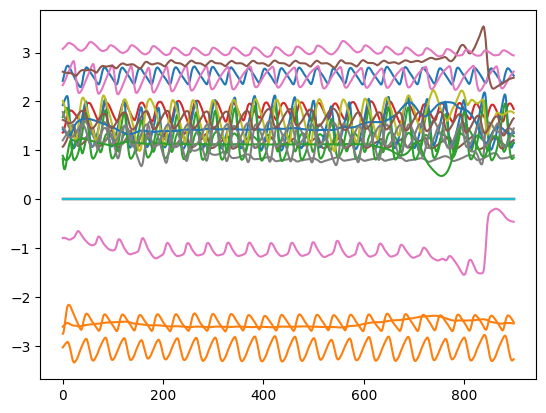

In [32]:

plt.plot(tg_angles)
plt.show()